# 08 — Eksplorasi Kualitas Anggur Merah

Apa yang membuat sebuah anggur merah dinilai "berkualitas"? Apakah kadar alkohol, keasaman, atau kandungan kimia lainnya? Di notebook ini saya akan menelusuri data laboratorium dari hampir 1600 sampel anggur untuk mencari jawabannya.

> 🎯 **Tujuan Pembelajaran**
> - Memahami dataset numerik dengan banyak fitur kimia.
> - Melihat **distribusi** skor kualitas anggur.
> - Mencari fitur yang paling **berkorelasi** dengan kualitas.
> - Mendeteksi **outlier** dengan boxplot.
> - Membaca **heatmap korelasi** untuk memahami hubungan antar fitur.


## 📊 Tentang Dataset

Kita memakai **Red Wine Quality** (Cortez et al., 2009), berisi 11 properti kimia
anggur merah Portugis ("Vinho Verde") beserta skor kualitas yang dinilai pakar.

- **Sumber:** [Kaggle — uciml/red-wine-quality-cortez-et-al-2009](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)
- **Jumlah data:** 1599 baris × 12 kolom

| Kolom | Arti |
|-------|------|
| `fixed acidity` | Keasaman tetap (asam tartarat) |
| `volatile acidity` | Keasaman menguap (asam asetat — terlalu tinggi = rasa cuka) |
| `citric acid` | Asam sitrat (menambah kesegaran) |
| `residual sugar` | Sisa gula |
| `chlorides` | Kadar garam |
| `free sulfur dioxide` | SO₂ bebas (pengawet) |
| `total sulfur dioxide` | Total SO₂ |
| `density` | Kepadatan |
| `pH` | Tingkat keasaman |
| `sulphates` | Sulfat (antioksidan) |
| `alcohol` | Kadar alkohol (%) |
| `quality` | Skor kualitas (0–10) — target penilaian |

## 1. Import Library

- **pandas** & **numpy** → mengolah tabel & angka.
- **matplotlib** & **seaborn** → visualisasi statistik.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Install Kaggle
!pip install -q Kaggle

In [3]:
#Download Dataset
!kaggle datasets download -d uciml/red-wine-quality-cortez-et-al-2009

Dataset URL: https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009
License(s): DbCL-1.0
100% 25.6k/25.6k [00:00<00:00, 41.7MB/s]



## Import Dataset

In [6]:
#Baca Dataset
df = pd.read_csv('/content/red-wine-quality-cortez-et-al-2009.zip')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Eksplorasi awal dataset

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [8]:
df.isnull().sum().sum()

np.int64(0)

Interpretasi:
- Semua tipe data bersifat numerical
- Tidak ada nilai yang hilang

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


Interpretasi:

  - Ukuran Dataset Lengkap: Seluruh 12 kolom memiliki total 1599 baris data (count = 1599.0), yang berarti dataset ini bersih dari missing value di tingkat awal.
  
  - Karakteristik Fisik Sangat Stabil (pH & Density): Memiliki nilai standar deviasi (std) yang sangat kecil (density 0.0018, pH 0.15), menunjukkan tingkat keasaman dan kepadatan sampel wine cenderung seragam.
  
  - Kadar Kimia Bervariasi Luas (Sulfur Dioxide): Kolom seperti total sulfur dioxide memiliki std tinggi (32.89) dengan rentang jauh dari 6 hingga 289, menandakan fluktuasi kandungan kimia yang sangat signifikan antar sampel.

  - Tingkat Kualitas (Quality): Rata-rata skor kualitas wine berada di angka 5.63 dengan nilai minimum 3 dan maksimum 8, di mana mayoritas sampel terkonsentrasi di angka 5 hingga 6 (berdasarkan kuartil 25% sampai 75%).

## 3. Memahami Variabel Target (quality)

Sebelum lanjut, mari lihat sebaran skor kualitas. Ini menentukan apakah datanya seimbang.

In [12]:
print(df['quality'].value_counts())

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


/tmp/ipykernel_6228/2551330465.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality', palette='rocket')


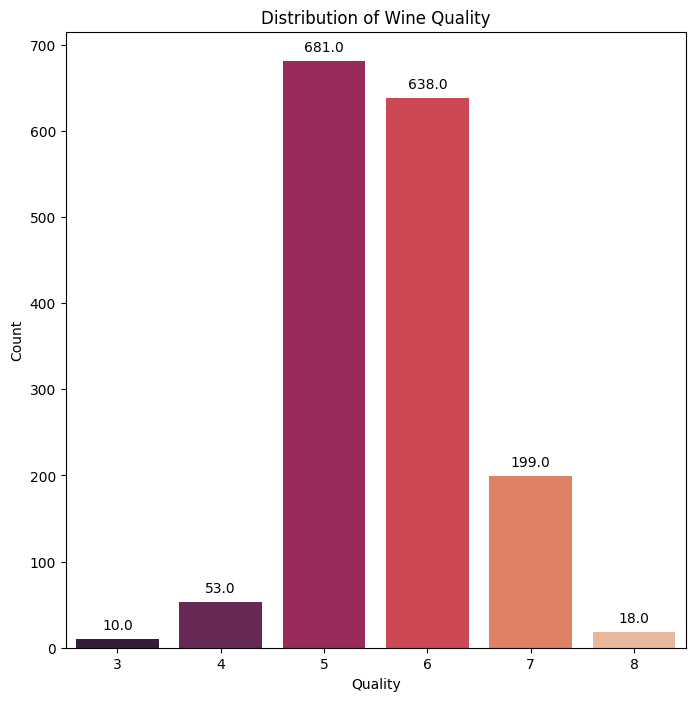

In [15]:
#Visualisasi kan quality
plt.figure(figsize=(8,8))
sns.countplot(data=df, x='quality', palette='rocket')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.title('Distribution of Wine Quality')
for p in plt.gca().patches:
    plt.annotate(f'{p.get_height()}', (p.get_x()+p.get_width()/2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
plt.show()

Interpretasi:
- Skor kualitas terpusat di angka 5 dan 6 ( majority anggur dengan kualitas biasa )
- anggur dengan kualitas 3 dan super quality 8, sangat jarang. data ini tidak seimbang
- Data ini Tidak seimbang, penting di ingat jika di gunakan untuk kasus klasifikasi nantinya

### EDA dana Klasifikasi

#### a) Heatmap korelasi antar fitur numerikal

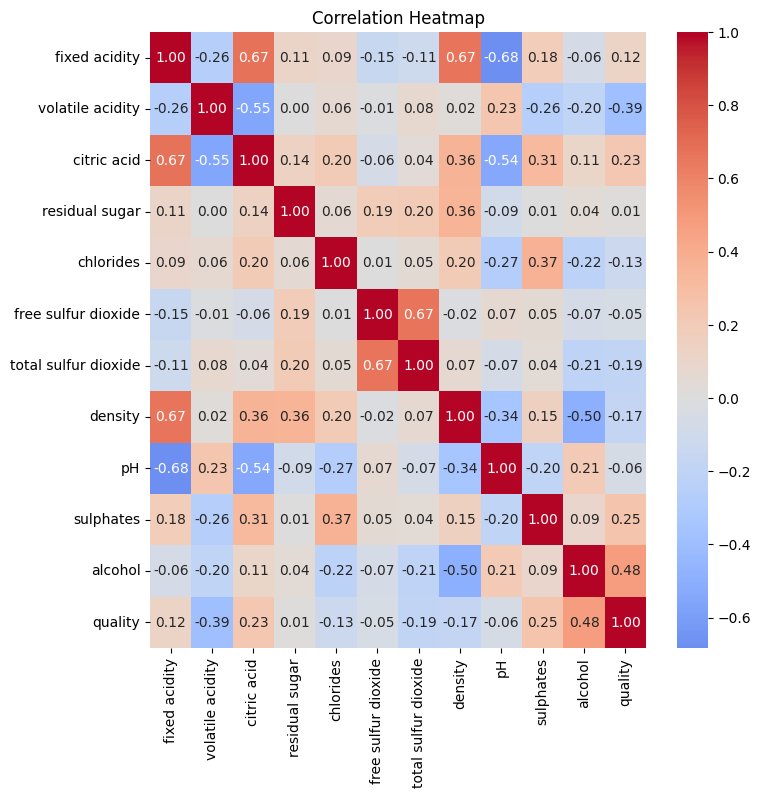

In [20]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

Interpretasi:

  - Faktor Penentu Utama (Quality): Kolom alcohol memiliki korelasi positif terkuat (0.48) terhadap kualitas, disusul sulphates (0.25) dan citric acid (0.23), yang berarti semakin tinggi nilai komponen ini, kualitas wine cenderung meningkat.

  - Faktor Perusak Utama (Quality): Kolom volatile acidity menunjukkan korelasi negatif terkuat (-0.39), menandakan bahwa tingginya kadar asam volatil dapat menurunkan skor kualitas wine secara signifikan.

  - Multikolinearitas Antar Fitur: Terdapat korelasi yang kuat antar fitur independen, seperti fixed acidity dengan pH (-0.68) serta fixed acidity dengan citric acid (0.67), yang perlu diwaspadai agar tidak terjadi redundansi informasi dalam model.

  - Fitur dengan Pengaruh Lemah: Beberapa fitur seperti residual sugar (0.01) dan free sulfur dioxide (-0.05) memiliki nilai korelasi yang mendekati nol terhadap quality, mengindikasikan hubungan linear langsung yang sangat lemah secara individual.

#### b) Korelasi setiap fitur terhadap quality

In [22]:
corr_quality = df.corr()['quality'].drop("quality").sort_values(ascending=False)
print(corr_quality)

alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


/tmp/ipykernel_6228/1290410619.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_quality.index, y=corr_quality, palette='rocket')


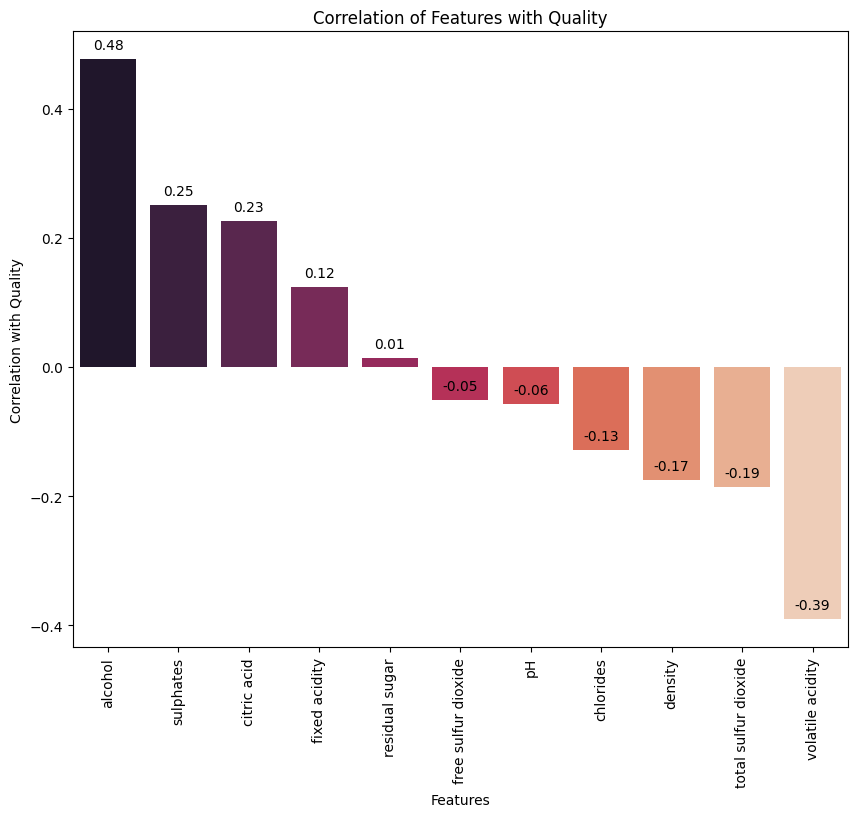

In [27]:
#visualiasikan dengan barplot
plt.figure(figsize=(10, 8))
sns.barplot(x=corr_quality.index, y=corr_quality, palette='rocket')
plt.xlabel('Features')
plt.ylabel('Correlation with Quality')
plt.xticks(rotation=90)
plt.title('Correlation of Features with Quality')
for p in plt.gca().patches:
    plt.annotate(f'{p.get_height():.2f}',
     (p.get_x() + p.get_width() / 2.,
      p.get_height()),
                 ha='center',
                 va='center',
                 xytext=(0, 10),
                 textcoords='offset points')
plt.show()

Interpretasi:

  - Prediktor Positif Terkuat (alcohol): Fitur alcohol memiliki nilai korelasi positif tertinggi sebesar 0.48, yang menunjukkan bahwa peningkatan kadar alkohol sangat sejalan dengan kenaikan skor quality.

  - Faktor Penunjang Positif Lainnya: sulphates (0.25), citric acid (0.23), dan fixed acidity (0.12) juga memberikan kontribusi positif terhadap kualitas, meskipun dengan kekuatan yang lebih rendah.

  - Fitur dengan Pengaruh Nyaris Nihil (residual sugar): residual sugar berada di angka 0.01, mengindikasikan bahwa kandungan gula sisa hampir tidak memiliki hubungan linear atau pengaruh langsung terhadap kualitas wine.

  - Korelasi Negatif Signifikan (volatile acidity): volatile acidity mencatatkan korelasi negatif terkuat di angka -0.39, yang berarti semakin tinggi kadar asam volatil, kualitas wine akan semakin turun drastis.

  - Faktor Negatif Pendukung: Fitur seperti total sulfur dioxide (-0.19), density (-0.17), chlorides (-0.13), pH (-0.06), dan free sulfur dioxide (-0.05) turut memberikan efek negatif, di mana peningkatan nilainya cenderung menurunkan skor kualitas.



#### c) Hubungan Alcohol dengan Quality ( BoxPlot )

/tmp/ipykernel_6228/753976598.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='alcohol', data=df, palette='rocket')


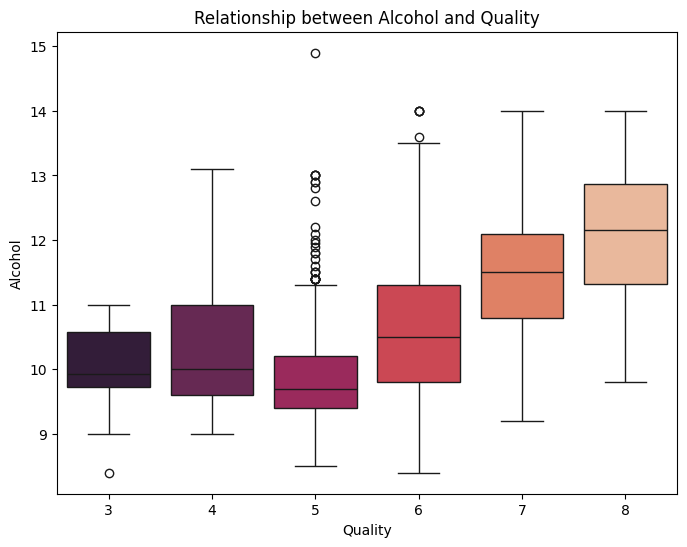

In [31]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='quality', y='alcohol', data=df, palette='rocket')
plt.xlabel('Quality')
plt.ylabel('Alcohol')
plt.title('Relationship between Alcohol and Quality')
plt.show()

Interpretasi:
  - Tren Positif Keseluruhan: Terdapat pola kenaikan median kadar alkohol seiring bertambahnya skor kualitas (terutama dari skor 5 ke 8), yang memperkuat temuan korelasi positif sebelumnya.

  - Analisis Outlier pada Skor 5 dan 6: Pada skor kualitas 5 terdapat banyak titik pencilan (outlier) di sisi atas (hingga mendekati angka 15), begitu juga pada skor 6 (di sekitar angka 14). Ini menunjukkan bahwa sebagian kecil sampel wine pada kategori kualitas menengah ini memiliki kadar alkohol yang jauh lebih tinggi dibandingkan mayoritas kelompoknya.

  - Konsentrasi Data pada Skor 5: Kotak (box) untuk skor 5 terlihat paling padat dengan rentang interkuartil yang sempit di bawah, mengindikasikan volume data terbanyak dalam dataset terkonsentrasi di sini, sehingga memunculkan banyak titik outlier di luar batas normal (whisker).

  - Keunikan Skor 3 dan 4: Menariknya, median alkohol pada skor kualitas 3 dan 4 sedikit lebih tinggi daripada skor 5, menunjukkan bahwa kadar alkohol yang tinggi saja tidak menjamin kualitas yang baik jika komponen penyeimbangnya tidak ideal.

  - Sikap terhadap Outlier untuk Model: Kita perlu memutuskan apakah outlier pada skor 5 dan 6 ini merupakan data valid (hasil pengukuran nyata yang sah) atau noise. Mengingat ini adalah analisis kimia wine, outlier tersebut adalah variasi alami yang sebaiknya dipertahankan kecuali terbukti salah catat

#### d) deteksi outlier pada beberapa fitur boxplot

/tmp/ipykernel_6228/1383483751.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=kol, data=df, ax=ax, palette='rocket')
/tmp/ipykernel_6228/1383483751.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=kol, data=df, ax=ax, palette='rocket')
/tmp/ipykernel_6228/1383483751.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=kol, data=df, ax=ax, palette='rocket')
/tmp/ipykernel_6228/1383483751.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.

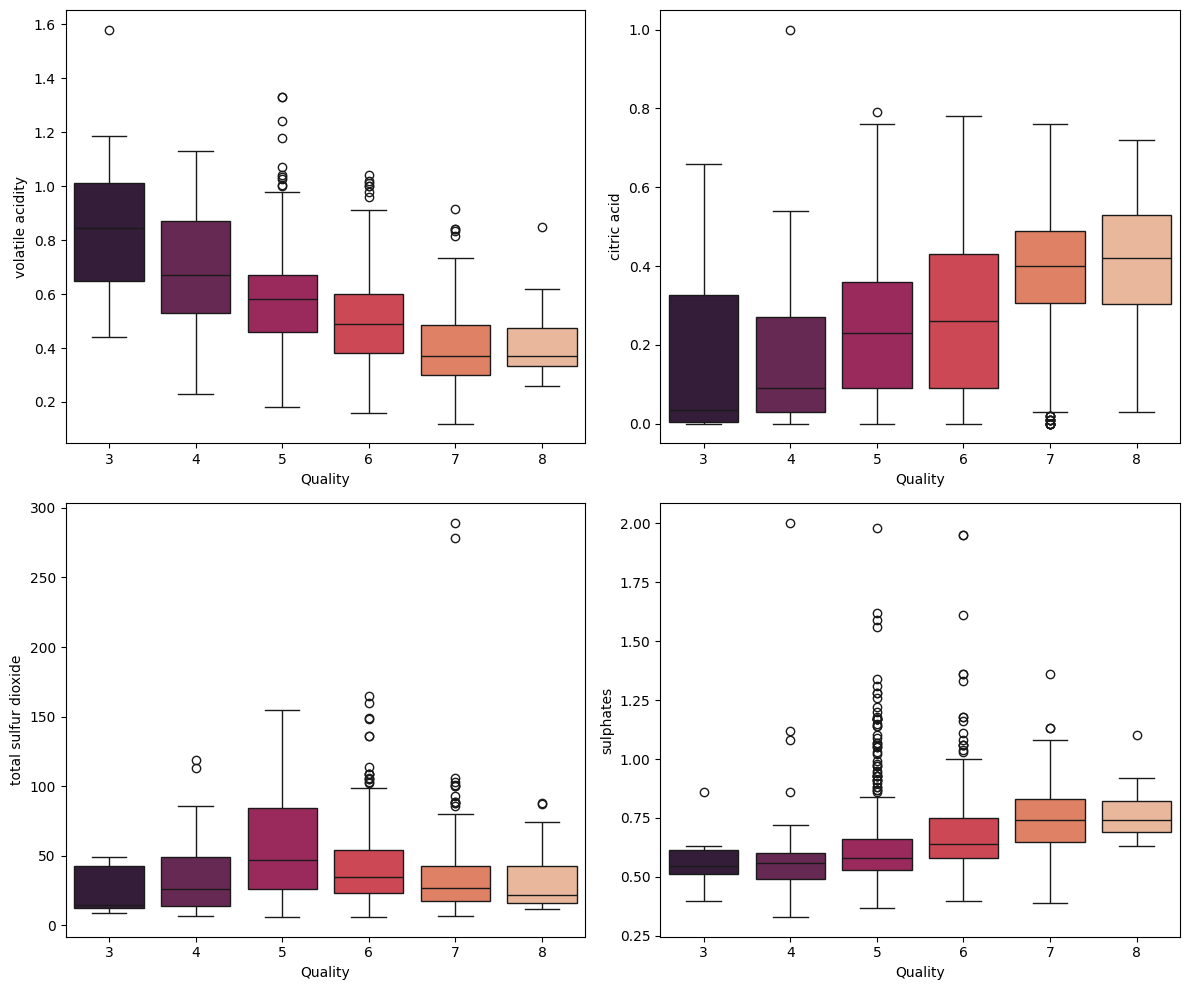

In [32]:
#cek outlier hanya kepada fitur yang berpengaruh ke hasil y
y_effect = ["volatile acidity", "citric acid", "total sulfur dioxide", "sulphates"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, kol in zip(axes.flatten(), y_effect):
    sns.boxplot(x='quality', y=kol, data=df, ax=ax, palette='rocket')
    ax.set_xlabel('Quality')
    ax.set_ylabel(kol)

plt.tight_layout()
plt.show()

Interpretasi:

-  **`volatile acidity` (Kiri Atas):** Menunjukkan tren penurunan yang konsisten; semakin tinggi skor kualitas, kadar asam volatil cenderung semakin rendah.
- **`citric acid` (Kanan Atas):** Menunjukkan tren peningkatan; wine dengan kualitas lebih tinggi umumnya memiliki kadar asam sitrat yang lebih tinggi.
- **`total sulfur dioxide` (Kiri Bawah):** Memiliki distribusi nilai yang meninggi pada kualitas menengah (skor 5) lalu menurun dan menyempit pada kualitas tinggi (skor 7–8).
- **`sulphates` (Kanan Bawah):** Menunjukkan tren kenaikan bertahap pada median dan batas kuartil seiring meningkatnya skor kualitas wine.

#### e) Distribusi volatile acidity dengan kualitas anggur

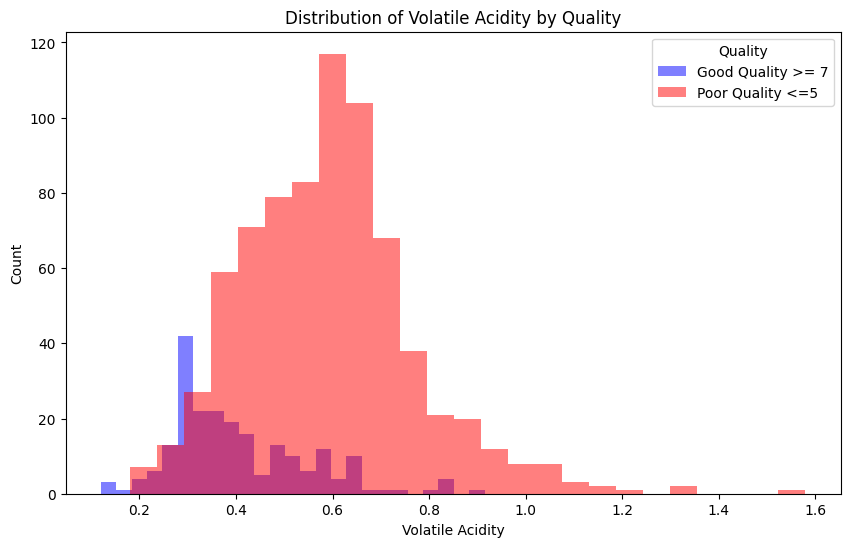

In [41]:
plt.figure(figsize=(10, 6))
q_baik= df[df["quality"]>=7]["volatile acidity"]
q_buruk = df[df["quality"]<=5]["volatile acidity"]

plt.hist(q_baik, bins=25, alpha=0.5, color='blue', label='Good Quality >= 7')
plt.hist(q_buruk, bins=25, alpha=0.5, color='red', label='Poor Quality <=5')


plt.xlabel('Volatile Acidity')
plt.ylabel('Count')
plt.title('Distribution of Volatile Acidity by Quality')
plt.legend(title='Quality', loc='upper right')
plt.show()

Interpretasi:

* **Pemisahan Kategori Target:** Grafik ini membandingkan distribusi `volatile acidity` antara wine berkualitas baik ($\ge 7$, warna biru) dan wine berkualitas buruk ($\le 5$, warna merah).
* **Konsentrasi Wine Buruk di Nilai Tinggi:** Sebaran data untuk wine berkualitas buruk mendominasi area nilai `volatile acidity` yang lebih tinggi (puncak tertingginya berada di kisaran 0.6 hingga 0.7).
* **Konsentrasi Wine Baik di Nilai Rendah:** Sebaliknya, wine berkualitas baik lebih banyak terkonsentrasi di sisi kiri dengan kadar asam volatil yang lebih rendah (puncak tertingginya di sekitar 0.3).
* **Validasi Fitur:** Grafik ini memperkuat temuan korelasi sebelumnya bahwa `volatile acidity` rendah merupakan indikator penting untuk menghasilkan wine dengan kualitas yang baik.

#### f) Pairplot Feature kunci berdasarkan quality class

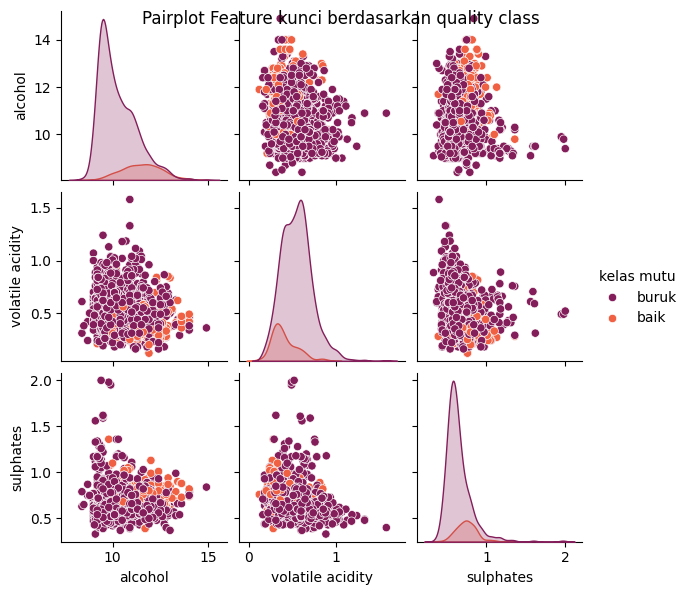

In [43]:
df["kelas mutu"] = np.where(df["quality"] >= 7, "baik", "buruk")

key_feature = ["alcohol", "volatile acidity", "sulphates", "kelas mutu"]

sns.pairplot(df[key_feature], hue="kelas mutu", palette="rocket",
             height=2.0)

plt.suptitle("Pairplot Feature kunci berdasarkan quality class")

plt.show()

Interpretasi:

* **Visualisasi Kombinasi Fitur (`Pairplot`):** Grafik ini menampilkan hubungan silang antar tiga fitur utama (`alcohol`, `volatile acidity`, dan `sulphates`) sekaligus untuk melihat bagaimana titik-titik data terkelompok berdasarkan kelas mutu (buruk vs baik).
* **Diagonal Utama (Distribusi Tunggal):** Grafik di jalur diagonal menampilkan kurva distribusi data (*KDE plot*) untuk masing-masing fitur, di mana mayoritas data kelas buruk (ungu tua) mendominasi volume sampel secara keseluruhan dibandingkan kelas baik (oranye).
* **Pola Interaksi Antar Variabel:** Grafik sebar (*scatter plot*) di luar diagonal menunjukkan bahwa titik-titik kelas baik (oranye) cenderung mengumpul di area tertentu, seperti pada kadar alkohol yang lebih tinggi atau kadar asam volatil yang lebih rendah.

## **Insight Utama Analisis Data Wine**

* **Prediktor Positif Terkuat (`alcohol`):** Kadar alkohol memiliki hubungan positif tertinggi (0.48) terhadap kualitas, di mana wine dengan skor mutu lebih tinggi konsisten menunjukkan median kadar alkohol yang lebih besar.
* **Faktor Perusak Mutu Utama (`volatile acidity`):** Asam volatil adalah faktor negatif terkuat (-0.39); sampel wine dengan kualitas buruk sangat terkonsentrasi pada tingkat `volatile acidity` yang tinggi.
* **Komponen Kimia Pendukung:** Fitur `sulphates` dan `citric acid` memberikan dukungan positif yang stabil terhadap peningkatan mutu, sementara variabel seperti `residual sugar` hampir tidak memiliki pengaruh linear yang berarti.
* **Pemisahan Kelas yang Jelas:** Berdasarkan grafik *pairplot* dan distribusi, kombinasi kadar alkohol yang tinggi dan asam volatil yang rendah menjadi pemisah karakteristik paling efektif antara kelas wine baik dan buruk.

**Kesimpulan**
Pengembangan model Machine Learning untuk memprediksi `quality` harus memprioritaskan fitur **`alcohol`** dan **`volatile acidity`** sebagai variabel prediktor utama, serta memasukkan **`sulphates`** dan **`citric acid`** sebagai fitur pendukung guna mencapai akurasi klasifikasi atau regresi yang optimal.

##Recommendasi dan Insight Bisnis

Berikut adalah rekomendasi dan *insight* bisnis berdasarkan hasil eksplorasi data kualitas wine yang telah Anda lakukan:

* **Fokuskan Strategi Produksi pada Pengendalian Asam Volatil:** Temuan menunjukkan bahwa *volatile acidity* adalah musuh utama kualitas wine dengan korelasi negatif yang kuat ($\mathbf{-0.39}$). Tim produksi atau *winemaker* harus menerapkan kontrol fermentasi yang ketat untuk menekan kadar asam volatil agar terhindar dari kategori mutu yang buruk.
* **Optimalkan Kadar Alkohol sebagai Nilai Jual (Value Driver):** Karena *alcohol* memiliki korelasi positif tertinggi ($\mathbf{0.48}$) terhadap skor kualitas, strategi formulasi atau pemilihan bahan baku fermentasi yang menghasilkan kadar alkohol optimal dapat langsung mendongkrak kelas mutu produk.
* **Gunakan Kombinasi Fitur Kunci untuk Klasifikasi Pasar:** Model machine learning atau sistem *grading* otomatis ke depan sebaiknya memprioritaskan variabel **`alcohol`**, **`volatile acidity`**, **`sulphates`**, dan **`citric acid`** sebagai parameter pengujian laboratorium utama sebelum produk dipasarkan.
* **Efisiensi Biaya Bahan Baku Pendukung:** Fitur seperti *residual sugar* terbukti memiliki korelasi yang hampir nihil ($\mathbf{0.01}$) terhadap kualitas. Perusahaan dapat menghemat alokasi atau penyesuaian bahan penunjang ini karena tidak memberikan dampak signifikan bagi kepuasan atau penilaian akhir konsumen.
